In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

#### 1. Загрузите изображение в оттенках серого.

shape: (519, 735) dtype: uint8


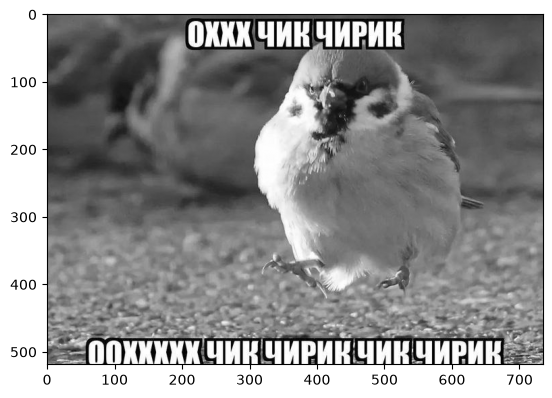

In [2]:
gray_image = cv2.imread('black-white-image.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(gray_image, cmap='gray')
print("shape:", gray_image.shape, "dtype:")

#### 2. Постройте гистограмму

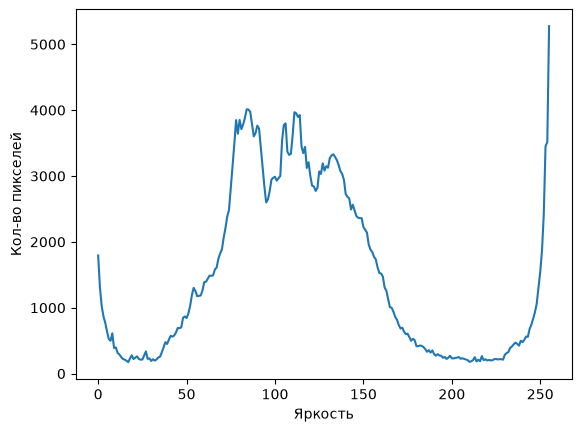

In [3]:
hist = cv2.calcHist([gray_image], [0], None, [256], [0, 256], accumulate=False)
plt.plot(hist)
plt.xlabel('Яркость')
plt.ylabel('Кол-во пикселей')
plt.show()

#### 3. Реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.

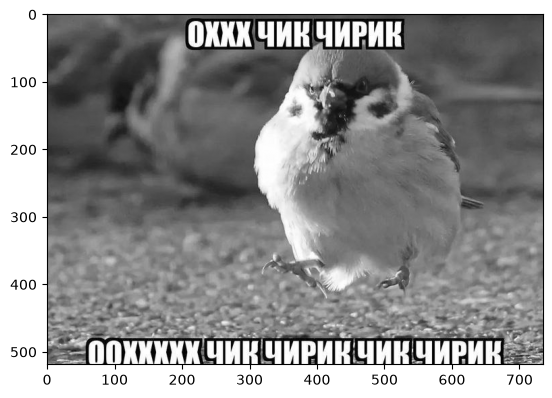

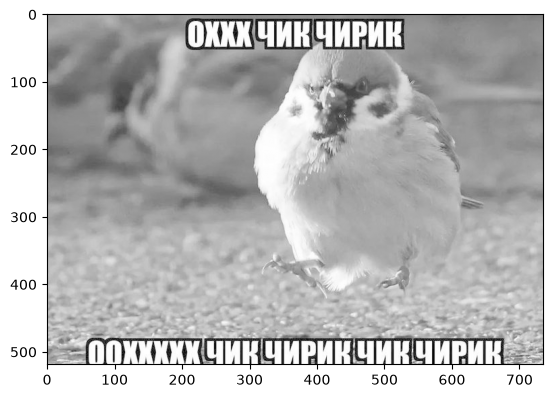

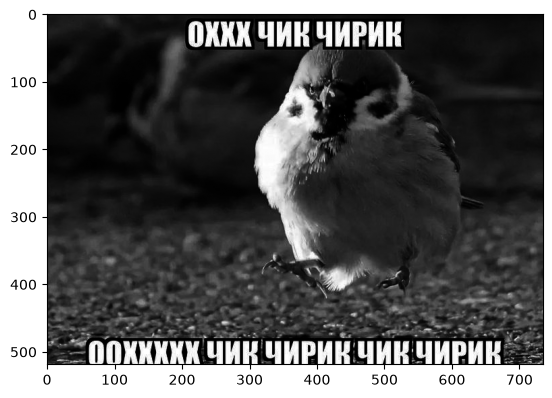

In [4]:
def gamma_correct(img, gamma):
    table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype('uint8')
    return cv2.LUT(img, table)

gamma_low  = gamma_correct(gray_image, 0.5)
gamma_high = gamma_correct(gray_image, 2.5)

plt.imshow(gray_image, cmap='gray')
plt.show()

plt.imshow(gamma_low, cmap='gray')
plt.show()

plt.imshow(gamma_high, cmap='gray')
plt.show()

#### 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

In [5]:
for name, img in [('gamma = 0.5', gamma_low), ('gamma = 2.5', gamma_high)]:
    ssim = structural_similarity(gray_image, img)
    mse  = mean_squared_error(gray_image, img)
    print(f"{name}:  SSIM = {ssim:.4f}   MSE = {mse:.2f}")

gamma = 0.5:  SSIM = 0.8873   MSE = 2728.67
gamma = 2.5:  SSIM = 0.5525   MSE = 4911.00


#### 5. Реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.

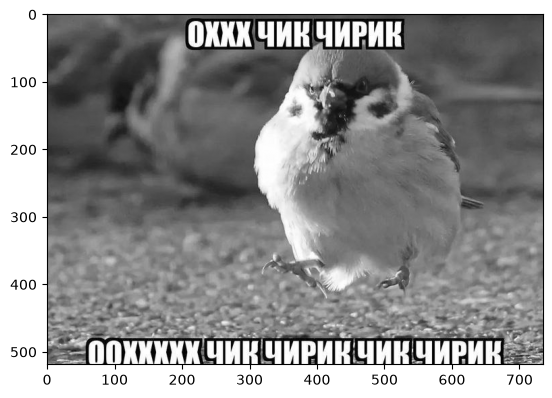

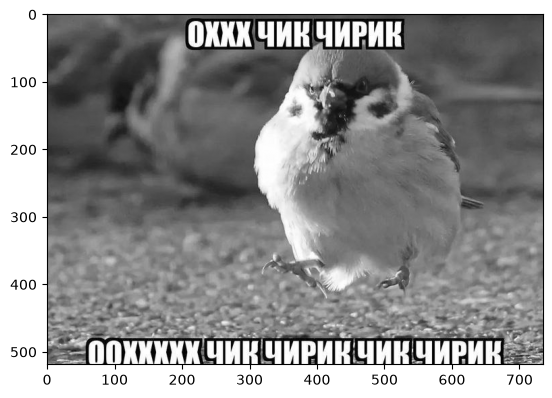

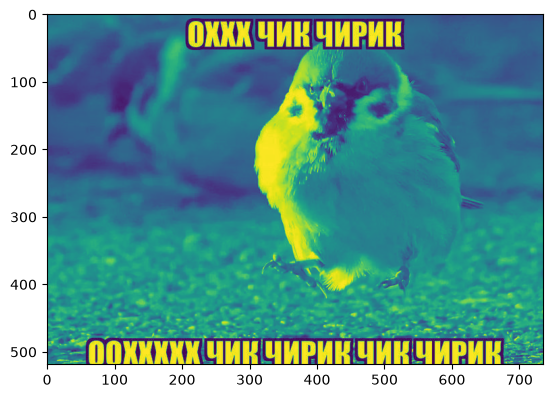

             mean    std
исходное:  118.96   54.25
после:     127.65   73.46
в цвете:   94.05   66.83
эталон чб: 127.65   73.46


In [10]:
colored_image = cv2.imread('sar_2_color.jpg')
colored_image_gray = cv2.cvtColor(colored_image, cv2.COLOR_BGR2GRAY) 
eq_gray = cv2.equalizeHist(colored_image_gray)

src_mean, src_std = gray_image.mean(), gray_image.std()
ref_mean, ref_std = eq_gray.mean(), eq_gray.std()

corrected = (gray_image - src_mean) * (ref_std / src_std) + ref_mean

plt.imshow(gray_image, cmap='gray')
plt.show()
plt.imshow(corrected, cmap='gray')
plt.show()

# Из интереса попробовал
# ----------------------------------------------------
hsv = cv2.cvtColor(colored_image, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
v_eq = cv2.equalizeHist(v)
hsv_eq = cv2.merge([h, s, v_eq])
eq_colored = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2BGR) 

sec_ref_mean, sec_ref_std = eq_colored.mean(), eq_colored.std()
sec_corrected = (gray_image - src_mean) * (sec_ref_std / src_std) + sec_ref_mean

plt.imshow(sec_corrected)
plt.show()
# ----------------------------------------------------

print("             mean    std")
print(f"исходное:  {src_mean:.2f}   {src_std:.2f}")
print(f"после:     {corrected.mean():.2f}   {corrected.std():.2f}")
print(f"в цвете:   {sec_corrected.mean():.2f}   {sec_corrected.std():.2f}")
print(f"эталон чб: {ref_mean:.2f}   {ref_std:.2f}")

#### 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

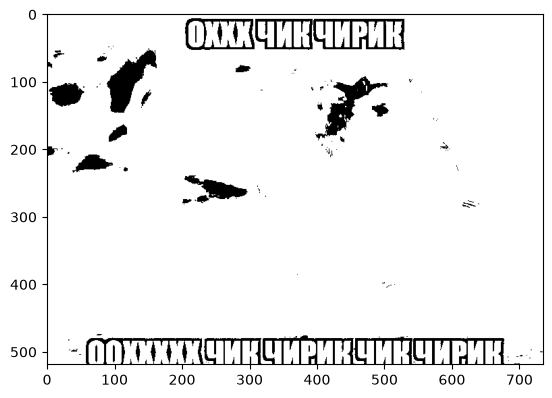

Порог 50: доля белых пикселей = 0.937


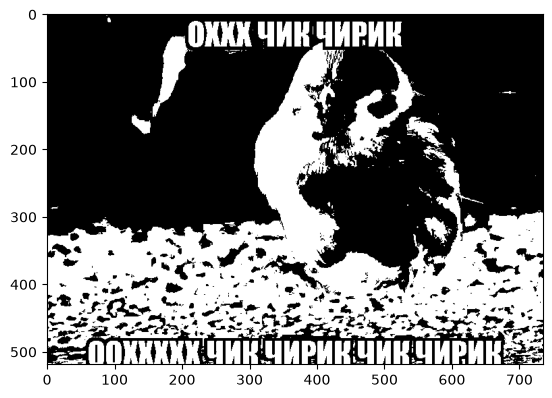

Порог 125: доля белых пикселей = 0.389


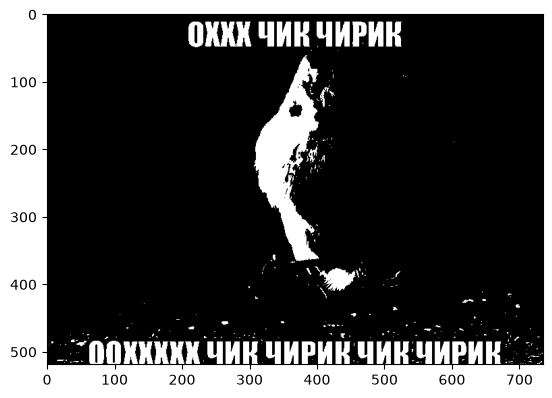

Порог 200: доля белых пикселей = 0.094


In [7]:
for t in [50, 125, 200]:
    _, th = cv2.threshold(gray_image, t, 255, cv2.THRESH_BINARY)
    plt.imshow(th, cmap='gray')
    plt.show()
    white_ratio = (th == 255).mean()
    print(f"Порог {t}: доля белых пикселей = {white_ratio:.3f}")